## Experiment No: 11
## Experiment Title: Reinforcement Learning using Q-Learning on a Grid World - Exploration-Exploitation and Optimal Policy

**Name:** Himanshu Jadhav  
**Roll Number:** TE-32

### Step 1: Import Required Libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(32)

print("Libraries imported successfully.")

Libraries imported successfully.


### Step 2: Define the Grid World Environment - The Shrine Trial
To make the exploration-exploitation dynamics genuinely visible (rather than trivially easy on a tiny grid), this experiment uses a **6x6 Grid World**, themed as a shrine maiden's trial: the agent starts at the **Shrine Gate** and must navigate to the **Inner Sanctum**, avoiding **Cursed Tiles** scattered across the path.

- **S** = Start (Shrine Gate)
- **G** = Goal (Inner Sanctum, reward +20)
- **T** = Trap / Cursed Tile (reward -15, episode ends)
- **.** = Normal path tile (reward -1 per step, encourages shorter paths)

In [2]:
GRID_SIZE = 6

START     = (0, 0)
GOAL      = (5, 5)
TRAPS     = [(1, 2), (2, 4), (3, 1), (4, 3), (0, 4), (5, 1), (2, 0)]

# Actions available: 0=Up, 1=Down, 2=Left, 3=Right
ACTIONS      = [0, 1, 2, 3]
ACTION_NAMES = {0: "Up", 1: "Down", 2: "Left", 3: "Right"}

# Print a text map of the shrine grounds
grid_display = np.full((GRID_SIZE, GRID_SIZE), ".", dtype=object)
grid_display[START] = "S"
grid_display[GOAL] = "G"
for t in TRAPS:
    grid_display[t] = "T"

print("Shrine Trial Grid World Created")
print(f"Grid Size           : {GRID_SIZE}x{GRID_SIZE}")
print(f"Start (Shrine Gate) : {START},\nGoal (Inner Sanctum): {GOAL}")
print(f"Cursed Tiles        : {TRAPS}\n")
print(pd.DataFrame(grid_display).to_string(index=False, header=False))

Shrine Trial Grid World Created
Grid Size           : 6x6
Start (Shrine Gate) : (0, 0),
Goal (Inner Sanctum): (5, 5)
Cursed Tiles        : [(1, 2), (2, 4), (3, 1), (4, 3), (0, 4), (5, 1), (2, 0)]

S . . . T .
. . T . . .
T . . . T .
. T . . . .
. . . T . .
. T . . . G


### Step 3: Define Environment Dynamics (Step Function)

In [3]:
def step(state, action):
    row, col = state

    if action == 0:   # Up
        row = max(row - 1, 0)
    elif action == 1: # Down
        row = min(row + 1, GRID_SIZE - 1)
    elif action == 2: # Left
        col = max(col - 1, 0)
    elif action == 3: # Right
        col = min(col + 1, GRID_SIZE - 1)
    
    next_state = (row, col)

    if next_state == GOAL:     # Goal reached
        reward = 20 
        done = True
    elif next_state in TRAPS:  # Trap encountered
        reward = -15
        done = True
    else:                      # Normal move
        reward = -1
        done = False
    
    return next_state, reward, done

print("\nStep function defined successfully.")


Step function defined successfully.


### Step 4: Initialize the Q-Table

In [4]:
q_table = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTIONS)))

print("Q-Table initialized with shape:", q_table.shape)
print("All Q-values start at 0 for each state-action pair.")

Q-Table initialized with shape: (6, 6, 4)
All Q-values start at 0 for each state-action pair.


### Step 5: Set Q-Learning Hyperparameters

In [5]:
alpha     = 0.1   # Learning rate
gamma     = 0.9   # Discount factor
epsilon   = 1.0   # Initial exploration rate
eps_min   = 0.01  # Minimum exploration rate
eps_decay = 0.995 # Decay rate for exploration

num_episodes          = 800
max_steps_per_episode = 100

print("\nTraining parameters set:")
print(f"Learning Rate   (alpha)      : {alpha}")
print(f"Discount Factor (gamma)      : {gamma}")
print(f"Initial Exploration Rate     : {epsilon}")
print(f"Minimum Exploration Rate     : {eps_min}")
print(f"Exploration Decay Rate       : {eps_decay}")
print(f"Number of Episodes           : {num_episodes}")
print(f"Maximum Steps per Episode    : {max_steps_per_episode}")



Training parameters set:
Learning Rate   (alpha)      : 0.1
Discount Factor (gamma)      : 0.9
Initial Exploration Rate     : 1.0
Minimum Exploration Rate     : 0.01
Exploration Decay Rate       : 0.995
Number of Episodes           : 800
Maximum Steps per Episode    : 100


### Step 6: Train the Agent using Q-Learning

In [6]:
episode_rewards = []
epsilon_values  = []

for episode in range(num_episodes):
    state        = START
    total_reward = 0

    for step_num in range(max_steps_per_episode):
        row, col = state

        # Epsilon-greedy strategy: explore randomly OR exploit the best known action
        if np.random.uniform(0, 1) < epsilon:
            action = np.random.choice(ACTIONS)     # Exploration
        else:
            action = np.argmax(q_table[row, col])  # Exploitation

        next_state, reward, done = step(state, action)
        next_row, next_col = next_state

        # Q-Learning update rule (Bellman equation)
        best_next_q = np.max(q_table[next_row, next_col])
        q_table[row, col, action] = q_table[row, col, action] + alpha * (
            reward + gamma * best_next_q - q_table[row, col, action]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    epsilon = max(eps_min, epsilon * eps_decay)
    episode_rewards.append(total_reward)
    epsilon_values.append(epsilon)

print("Training completed!")
print(f"Final epsilon value: {epsilon:.4f}")
print(f"Average reward (last 50 episodes): {np.mean(episode_rewards[-50:]):.2f}")

Training completed!
Final epsilon value: 0.0181
Average reward (last 50 episodes): 10.24


### Step 7: Visualize Learning Progress (Reward per Episode)

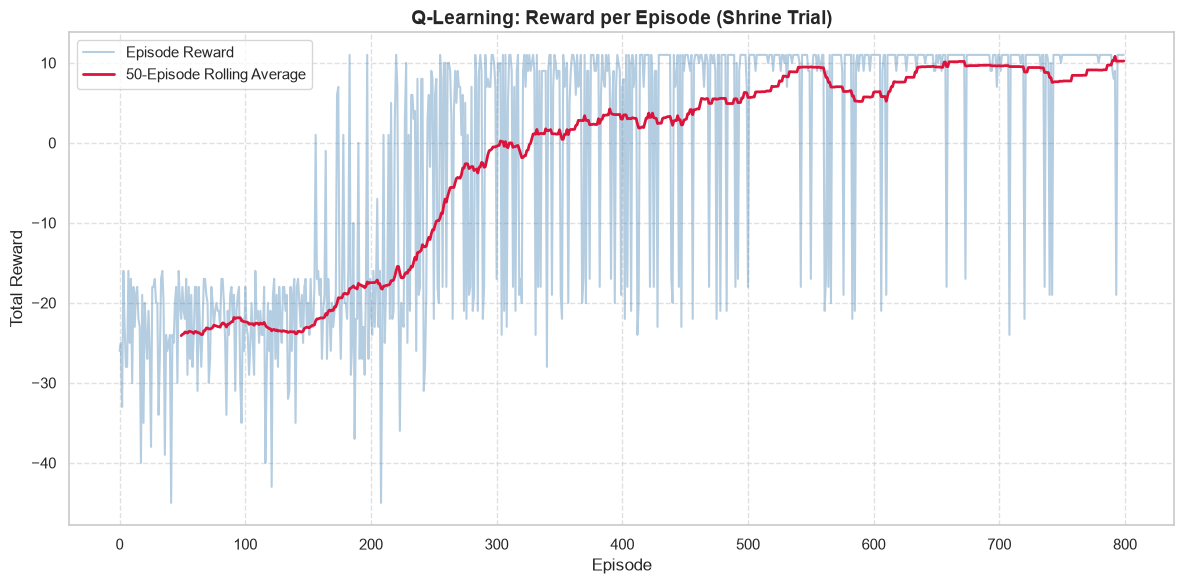

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(episode_rewards, label="Episode Reward", color='steelblue', alpha=0.4)

rolling_avg = pd.Series(episode_rewards).rolling(window=50).mean()
plt.plot(rolling_avg, label="50-Episode Rolling Average", color='crimson', linewidth=2)

plt.title("Q-Learning: Reward per Episode (Shrine Trial)", fontsize=14, fontweight='bold')
plt.xlabel("Episode", fontsize=12)
plt.ylabel("Total Reward", fontsize=12)
plt.legend(loc="best", fontsize=11, frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


### Step 8: Visualize the Exploration-Exploitation Trade-off (Epsilon Decay)

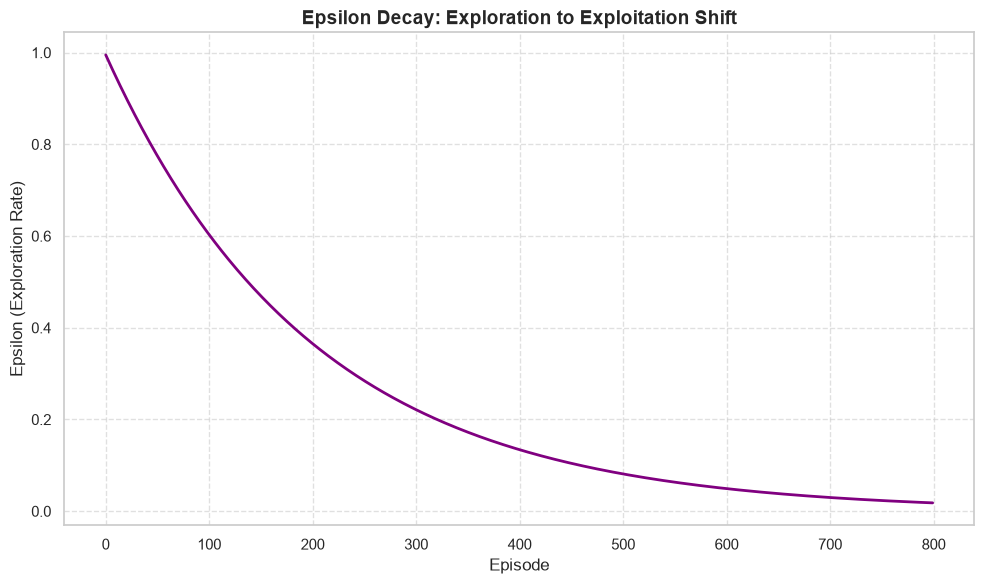

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(epsilon_values, color="purple", linewidth=2)

plt.xlabel("Episode", fontsize=12)
plt.ylabel("Epsilon (Exploration Rate)", fontsize=12)
plt.title("Epsilon Decay: Exploration to Exploitation Shift", fontsize=14, fontweight="bold")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


### Step 9: Extract and Visualize the Learned Optimal Policy

Learned Optimal Policy (Grid View):

> v > v T ^
> v T v > v
T > > v T v
< T > > > v
< < < T > v
< T > > > G


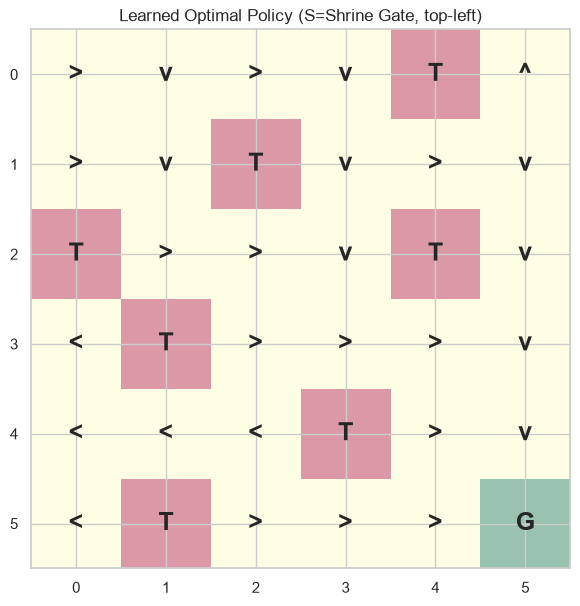

In [9]:
policy_grid = np.full((GRID_SIZE, GRID_SIZE), "", dtype=object)
arrow_map   = {0: "^", 1: "v", 2: "<", 3: ">"}

for row in range(GRID_SIZE):
    for col in range(GRID_SIZE):
        state = (row, col)
        if state == GOAL:
            policy_grid[row, col] = "G"
        elif state in TRAPS:
            policy_grid[row, col] = "T"
        else:
            best_action = np.argmax(q_table[row, col])
            policy_grid[row, col] = arrow_map[best_action]

print("Learned Optimal Policy (Grid View):\n")
policy_df = pd.DataFrame(policy_grid)
print(policy_df.to_string(index=False, header=False))

fig, ax = plt.subplots(figsize=(7, 7))
bg      = np.zeros((GRID_SIZE, GRID_SIZE))
for t in TRAPS:
    bg[t] = -1
bg[GOAL]  = 1

ax.imshow(bg, cmap="RdYlGn", alpha=0.4)
for row in range(GRID_SIZE):
    for col in range(GRID_SIZE):
        ax.text(col, row, policy_grid[row, col], ha="center", va="center", fontsize=18, fontweight="bold")

ax.set_xticks(range(GRID_SIZE))
ax.set_yticks(range(GRID_SIZE))
ax.set_title("Learned Optimal Policy (S=Shrine Gate, top-left)")
plt.show()

### Step 10: Test the Trained Agent (Follow the Learned Policy)


Path taken by trained agent (Shrine Gate -> Inner Sanctum):
(0, 0) -> (0, 1) -> (1, 1) -> (2, 1) -> (2, 2) -> (2, 3) -> (3, 3) -> (3, 4) -> (3, 5) -> (4, 5) -> (5, 5)

Total reward collected: 11
Steps taken: 10
Reached the Inner Sanctum!

Results DataFrame:
    Step   State
0      0  (0, 0)
1      1  (0, 1)
2      2  (1, 1)
3      3  (2, 1)
4      4  (2, 2)
5      5  (2, 3)
6      6  (3, 3)
7      7  (3, 4)
8      8  (3, 5)
9      9  (4, 5)
10    10  (5, 5)


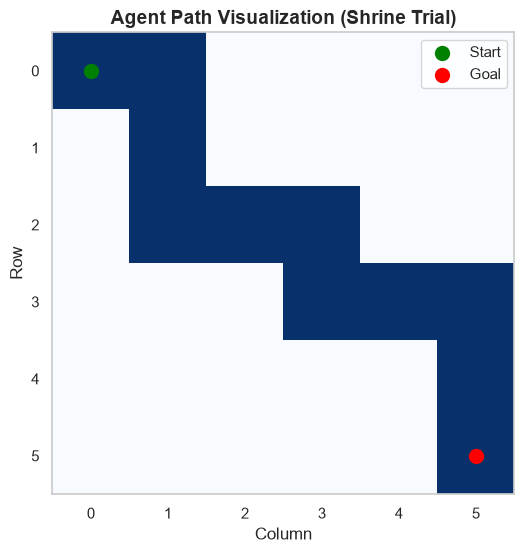

In [10]:
state = START
path  = [state]
total_reward = 0

for step_num in range(max_steps_per_episode):
    row, col = state
    action = np.argmax(q_table[row, col])
    next_state, reward, done = step(state, action)
    path.append(next_state)
    total_reward += reward
    state = next_state
    if done:
        break

steps_taken = len(path) - 1

print("\nPath taken by trained agent (Shrine Gate -> Inner Sanctum):")
print(" -> ".join(map(str, path)))
print(f"\nTotal reward collected: {total_reward}")
print(f"Steps taken: {steps_taken}")
print("Reached the Inner Sanctum!" if state == GOAL else "Fell into a Cursed Tile or ran out of steps.")

results_df = pd.DataFrame({
    "Step" : range(len(path)),
    "State": path
})
print("\nResults DataFrame:")
print(results_df)

grid_size = (q_table.shape[0], q_table.shape[1])
grid = np.zeros(grid_size)

for r, c in path:
    grid[r, c] = 1

plt.figure(figsize=(6, 6))
plt.imshow(grid, cmap="Blues", origin="upper")
plt.title("Agent Path Visualization (Shrine Trial)", fontsize=14, fontweight="bold")
plt.xlabel("Column")
plt.ylabel("Row")

start_row, start_col = START
goal_row,  goal_col  = GOAL
plt.scatter(start_col, start_row, color="green", s=100, label="Start")
plt.scatter(goal_col, goal_row, color="red", s=100, label="Goal")

plt.legend()
plt.grid(False)
plt.show()


### Step 11: Final Output

In [11]:
print(f"\nFinal Average Reward (last 50 episodes): {np.mean(episode_rewards[-50:]):.2f}")
print(f"Path followed by trained agent: {' -> '.join(str(p) for p in path)}")
print(f"Outcome: {'Goal Reached' if state == GOAL else 'Failed'}")


Final Average Reward (last 50 episodes): 10.24
Path followed by trained agent: (0, 0) -> (0, 1) -> (1, 1) -> (2, 1) -> (2, 2) -> (2, 3) -> (3, 3) -> (3, 4) -> (3, 5) -> (4, 5) -> (5, 5)
Outcome: Goal Reached
